In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [2]:
# --- 1. Data Loading and Initial Inspection ---
file_path = "Area distances.xlsx - Sheet1.csv"
df = pd.read_csv("C:/Users/ACCENTURE ICT/Downloads/Area distances.csv")

In [4]:
# Rename columns for easier access and clarity
df.columns = [
    'Area', 'Cost_20t', 'Cost_30t', 'Radius_km'
]

In [7]:
# Convert relevant columns to numeric, coercing errors to NaN
for col in ['Cost_20t', 'Cost_30t', 'Radius_km']:
    # Replace comma decimal with dot decimal (if present), and then convert to numeric
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with any missing values in the modeling columns
df_clean = df.dropna(subset=['Cost_20t', 'Cost_30t', 'Radius_km'])

# Define feature (X) and target columns (Y)
X = df_clean[['Radius_km']]
Y_20t = df_clean['Cost_20t']
Y_30t = df_clean['Cost_30t']

In [8]:
# Split data (using the same split for both targets for consistency)
X_train, X_test, y_20t_train, y_20t_test = train_test_split(
    X, Y_20t, test_size=0.2, random_state=42
)
_, _, y_30t_train, y_30t_test = train_test_split(
    X, Y_30t, test_size=0.2, random_state=42
)


In [9]:

# --- 2. Model Training and Evaluation Function ---

def train_and_evaluate_models(X_train, X_test, y_train, y_test, target_name):
    """Trains and evaluates Linear Regression, Random Forest, and KNN models."""

    # Initialize models
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(random_state=42),
        'KNN': KNeighborsRegressor(n_neighbors=5) 
    }

    results = []
    
    for name, model in models.items():
        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Evaluate
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        results.append({
            'Model': name,
            'R2 Score': r2,
            'MAE': mae,
            'RMSE': rmse
        })

    results_df = pd.DataFrame(results).set_index('Model')
    return results_df


In [10]:
# --- 3. Run Modeling for 20t and 30t Tipper Costs ---

results_20t = train_and_evaluate_models(
    X_train, X_test, y_20t_train, y_20t_test, "20t Tipper Cost"
)
results_30t = train_and_evaluate_models(
    X_train, X_test, y_30t_train, y_30t_test, "30t Tipper Cost"
)

# Combine results for comparison
results_20t.columns = [col + ' (20t)' for col in results_20t.columns]
results_30t.columns = [col + ' (30t)' for col in results_30t.columns]
comparison_df = pd.concat([results_20t, results_30t], axis=1)


In [11]:
# Write out the comparison results
comparison_df.to_csv('model_performance_comparison.csv')

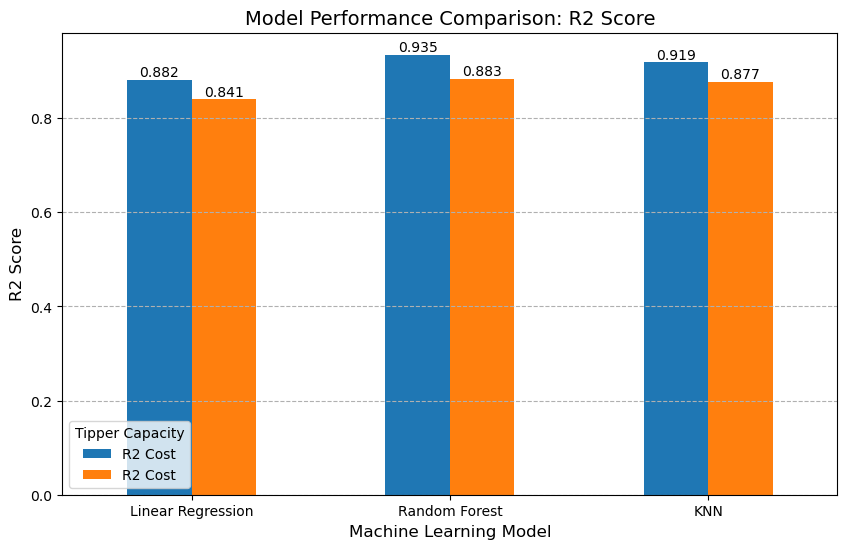

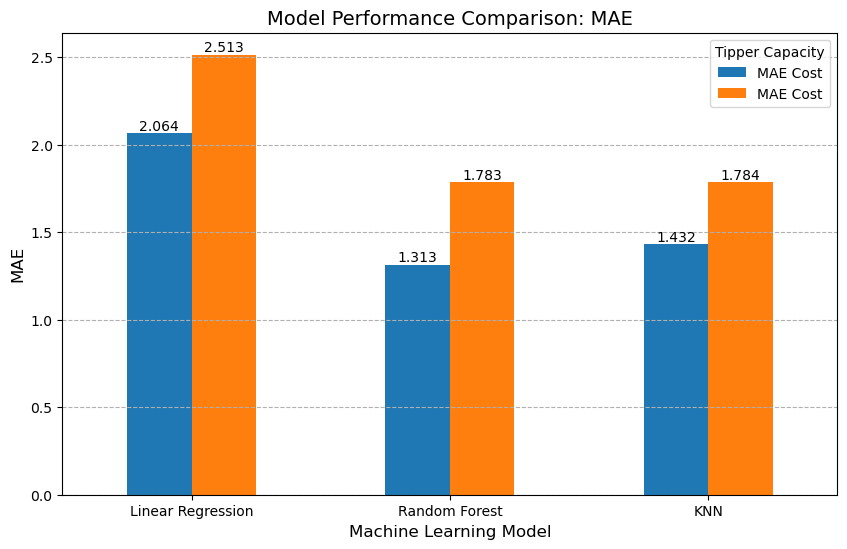

In [12]:

# --- 4. Visualizations: Model Performance Comparison Graphs ---

def plot_performance_metrics(comparison_df, metric_name, filename):
    """Generates a grouped bar chart for model performance comparison."""
    
    # Prepare data for plotting the specific metric
    metric_cols = [col for col in comparison_df.columns if metric_name in col]
    plot_data = comparison_df[metric_cols]
    
    # Rename columns for chart legend
    plot_data.columns = [col.split(' ')[0] + ' Cost' for col in plot_data.columns]
    
    ax = plot_data.plot(kind='bar', figsize=(10, 6))
    
    # Annotate bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f')

    # Formatting
    ax.set_title(f'Model Performance Comparison: {metric_name}', fontsize=14)
    ax.set_xlabel('Machine Learning Model', fontsize=12)
    ax.set_ylabel(metric_name, fontsize=12)
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--')
    plt.legend(title='Tipper Capacity')
    

# Plot R2 Scores
plot_performance_metrics(comparison_df, 'R2 Score', 'R2_Score_Comparison.png')

# Plot MAE Scores
plot_performance_metrics(comparison_df, 'MAE', 'MAE_Comparison.png')



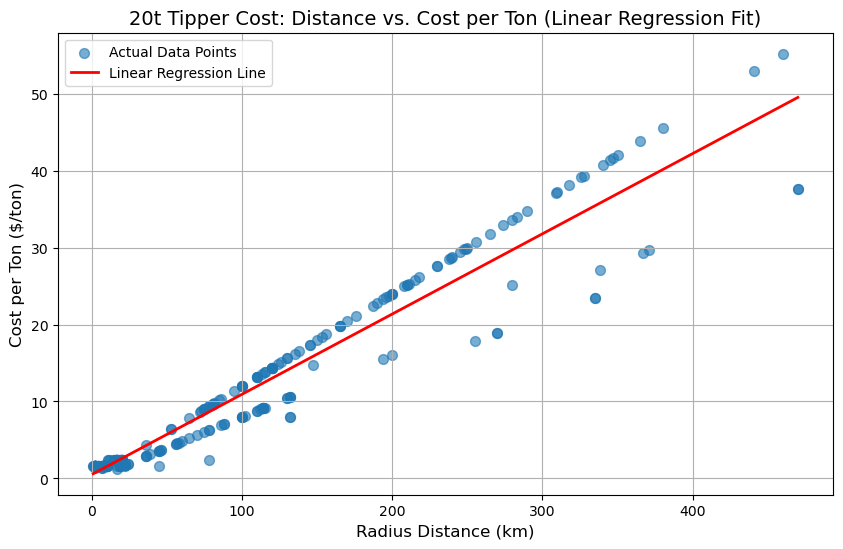

In [14]:

# --- 5. Visualizations: Distance vs. Cost Plots (using Linear Regression for trend) ---

# Retrain Linear Regression models on the full dataset for prediction plots
lr_20t = LinearRegression().fit(X, Y_20t)
lr_30t = LinearRegression().fit(X, Y_30t)

# FIX: Create a sequence of distance values and convert to DataFrame to maintain feature names
X_range_np = np.linspace(X['Radius_km'].min(), X['Radius_km'].max(), 50)
X_range_df = pd.DataFrame(X_range_np, columns=['Radius_km'])

Y_pred_20t_range = lr_20t.predict(X_range_df)
Y_pred_30t_range = lr_30t.predict(X_range_df)

# Plot 20t Tipper Cost
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Radius_km'], df_clean['Cost_20t'], label='Actual Data Points', alpha=0.6, s=50)
plt.plot(X_range_df['Radius_km'], Y_pred_20t_range, color='red', linewidth=2, label='Linear Regression Line')
plt.title('20t Tipper Cost: Distance vs. Cost per Ton (Linear Regression Fit)', fontsize=14)
plt.xlabel('Radius Distance (km)', fontsize=12)
plt.ylabel('Cost per Ton (\$/ton)', fontsize=12)
plt.legend()
plt.grid(True)






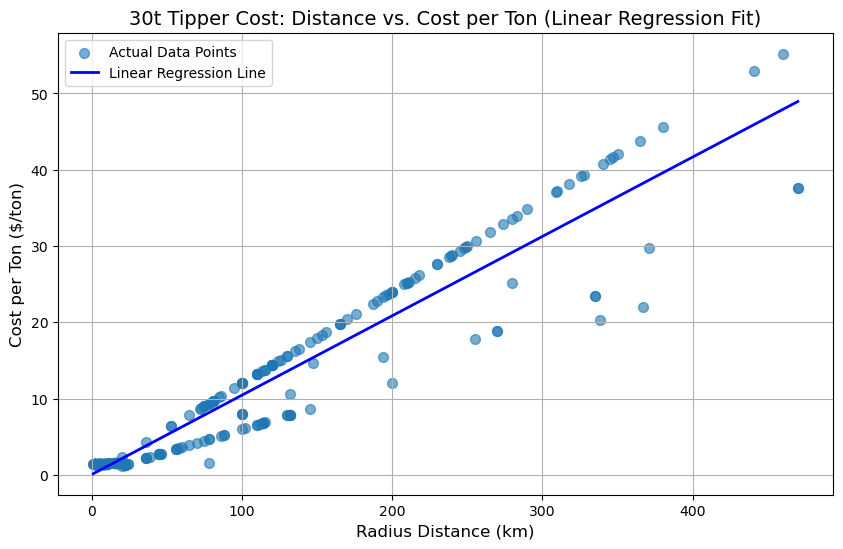

In [15]:

# Plot 30t Tipper Cost
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Radius_km'], df_clean['Cost_30t'], label='Actual Data Points', alpha=0.6, s=50)
plt.plot(X_range_df['Radius_km'], Y_pred_30t_range, color='blue', linewidth=2, label='Linear Regression Line')
plt.title('30t Tipper Cost: Distance vs. Cost per Ton (Linear Regression Fit)', fontsize=14)
plt.xlabel('Radius Distance (km)', fontsize=12)
plt.ylabel('Cost per Ton (\$/ton)', fontsize=12)
plt.legend()
plt.grid(True)
